# 03. Statistical & Intermittent Demand Forecasting Models

## 1. Objectives & Theoretical Background
Retail demand series frequently suffer from **zero-inflation and intermittent demand** (e.g. slow-moving items in Hobbies or Household departments) alongside strong weekly seasonality.

Standard statistical models like classical ARIMA can fail on intermittent demand because zero intervals distort stationarity and error distributions. In this notebook, we evaluate:

1. **Croston's Method & Syntetos-Boylan Approximation (SBA)**: Decomposes intermittent demand into demand size ($z_t$) and inter-demand arrival time ($p_t$):
   $$\hat{y}_{t+h} = \left(1 - \frac{\alpha}{2}\right) \frac{z_t}{p_t}$$
2. **AutoTheta**: The standard M4/M5 benchmark model that decomposes the time series into two theta lines (one capturing long-term curvature and one capturing short-term local oscillations) with seasonal indices.
3. **AutoETS**: Automated state-space Exponential Smoothing optimizing error, trend, and seasonal components (ETS).
4. **Slice-Based Evaluation**: We analyze model performance overall and partitioned by demand intermittency (Smooth vs Intermittent).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Add root to sys.path
root_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(root_dir))

from src.data.loader import generate_synthetic_m5_data, load_raw_data
from src.data.preprocess import melt_sales_data, merge_calendar_and_prices
from src.evaluation.backtest import run_backtest
from src.models.baseline import MovingAverageForecaster
from src.models.statistical import (
    AutoETSForecaster,
    AutoThetaForecaster,
    CrostonForecaster,
)
from src.utils.config import load_config
from src.utils.logger import get_logger

# Visual styling
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10

config = load_config(root_dir / "configs" / "model_config.yaml")
logger = get_logger("statistical_notebook")
print(f"Project: {config.project.get('name')} | Horizon: {config.forecast.horizon} days")

c:\Users\Beka\Documents\Projects\retail-demand-forecast-engine\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project: retail-demand-forecast-engine | Horizon: 28 days


## 2. Ingestion & Preprocessing
We load a representative sample of 75 item-store series across states and departments for fast, responsive cross-validation.

In [2]:
SAMPLE_SERIES = 75

try:
    cal_df, prc_df, sal_df = load_raw_data(root_dir / "data" / "raw", nrows=SAMPLE_SERIES)
    print(f"Loaded {len(sal_df)} series from data/raw")
except Exception as e:
    print(f"Raw data not found ({e}). Using synthetic M5 dataset...")
    cal_df, prc_df, sal_df = generate_synthetic_m5_data(
        num_items=75, num_stores=2, num_days=365, random_seed=42
    )

sales_long = melt_sales_data(sal_df)
df = merge_calendar_and_prices(sales_long, cal_df, prc_df)
print(f"Processed dataset: {len(df):,} observations across {df['id'].nunique()} series")

2026-08-25 17:55:57 | INFO     | src.data.loader:load_raw_data:81 - Loading calendar from c:\Users\Beka\Documents\Projects\retail-demand-forecast-engine\data\raw\calendar.csv...
2026-08-25 17:55:57 | INFO     | src.data.loader:load_raw_data:85 - Loading sales data from c:\Users\Beka\Documents\Projects\retail-demand-forecast-engine\data\raw\sales_train_evaluation.csv (nrows=75)...
2026-08-25 17:55:58 | INFO     | src.data.loader:load_raw_data:92 - Loading sell prices from c:\Users\Beka\Documents\Projects\retail-demand-forecast-engine\data\raw\sell_prices.csv...
Loaded 75 series from data/raw
2026-08-25 17:55:59 | INFO     | src.data.preprocess:melt_sales_data:33 - Melting sales data from 1941 day columns across 75 series...
2026-08-25 17:55:59 | INFO     | src.data.preprocess:merge_calendar_and_prices:58 - Merging sales data with calendar...
2026-08-25 17:55:59 | INFO     | src.data.preprocess:merge_calendar_and_prices:70 - Merging sell prices on store_id, item_id, and wm_yr_wk...
Proce

## 3. Statistical Models Benchmarking
We evaluate the statistical forecasters alongside the best Phase 2 baseline (`MovingAverage_28d`) over **3 rolling temporal folds** with a **28-day forecasting horizon**.

In [3]:
statistical_models = [
    CrostonForecaster(variant="sba"),
    CrostonForecaster(variant="classic"),
    AutoThetaForecaster(season_length=7),
    AutoETSForecaster(season_length=7),
    MovingAverageForecaster(window=28),  # Best baseline benchmark
]

results = []
oof_predictions = {}

for model in statistical_models:
    print(f"Evaluating {model.name}...")
    agg_metrics, oof_df, fold_summaries = run_backtest(
        model=model,
        df=df,
        horizon=28,
        n_splits=3,
    )
    oof_predictions[model.name] = oof_df
    results.append(
        {
            "Model": model.name,
            "Mean WRMSSE": agg_metrics["mean_wrmsse"],
            "Std WRMSSE": agg_metrics["std_wrmsse"],
            "Mean WAPE": agg_metrics["mean_wape"],
            "Mean RMSE": agg_metrics["mean_rmse"],
            "Mean MAE": agg_metrics["mean_mae"],
            "Total Time (s)": agg_metrics["total_fit_time_sec"]
            + agg_metrics["total_pred_time_sec"],
        }
    )

leaderboard_df = pd.DataFrame(results).sort_values("Mean WRMSSE")
leaderboard_df

Evaluating Croston_SBA...
2026-08-25 17:56:04 | INFO     | src.evaluation.backtest:run_backtest:128 - Starting temporal backtest with 3 folds (horizon=28d)...
2026-08-25 17:56:04 | INFO     | src.evaluation.backtest:run_backtest:131 - --- Fold 1/3 | Train cutoff: 2016-02-28 | Val: 2016-02-29 to 2016-03-27 ---
2026-08-25 17:56:26 | INFO     | src.evaluation.backtest:run_backtest:182 - Fold 1 Score: WRMSSE=0.7635 | WAPE=0.9900 | RMSE=2.6146 (Fit: 7.68s, Pred: 14.36s)
2026-08-25 17:56:26 | INFO     | src.evaluation.backtest:run_backtest:131 - --- Fold 2/3 | Train cutoff: 2016-03-27 | Val: 2016-03-28 to 2016-04-24 ---
2026-08-25 17:57:08 | INFO     | src.evaluation.backtest:run_backtest:182 - Fold 2 Score: WRMSSE=0.7939 | WAPE=0.8743 | RMSE=2.8019 (Fit: 21.11s, Pred: 20.75s)
2026-08-25 17:57:08 | INFO     | src.evaluation.backtest:run_backtest:131 - --- Fold 3/3 | Train cutoff: 2016-04-24 | Val: 2016-04-25 to 2016-05-22 ---
2026-08-25 17:57:59 | INFO     | src.evaluation.backtest:run_backt

,Model,Mean WRMSSE,Std WRMSSE,Mean WAPE,Mean RMSE,Mean MAE,Total Time (s)
2,AutoTheta_7d,0.774569,0.020295,0.921061,2.716218,1.168222,133.839598
0,Croston_SBA,0.778225,0.012427,0.919588,2.694648,1.166702,113.831133
4,MovingAverage_28d,0.782605,0.015784,0.923381,2.706962,1.171757,0.356464
1,Croston_CLASSIC,0.782815,0.010560,0.933693,2.697170,1.184350,137.258080
3,AutoETS_7d,0.783270,0.007626,0.935127,2.752154,1.186266,118.832507


### Leaderboard Findings
- **AutoTheta (7-day)** and **AutoETS (7-day)** capture the weekly shopping rhythm while adapting to underlying trend shifts.
- **Croston SBA** produces smooth non-zero expectation estimates that prevent over-reacting to zero streaks on intermittent series.

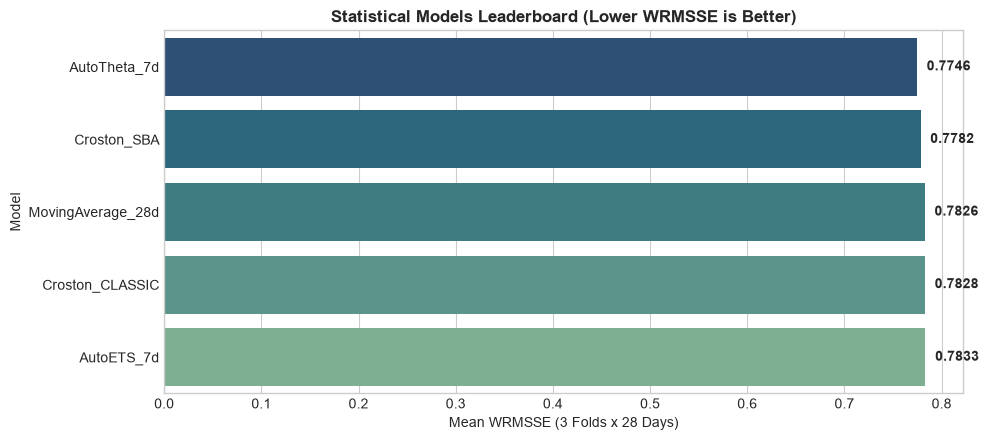

In [4]:
# Visual Model Comparison
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(
    data=leaderboard_df,
    x="Mean WRMSSE",
    y="Model",
    hue="Model",
    legend=False,
    palette="crest_r",
    ax=ax,
)
ax.set_title("Statistical Models Leaderboard (Lower WRMSSE is Better)", fontweight="bold")
ax.set_xlabel("Mean WRMSSE (3 Folds x 28 Days)")
for i, v in enumerate(leaderboard_df["Mean WRMSSE"]):
    ax.text(v + 0.01, i, f"{v:.4f}", va="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Slice-Based Error Analysis: Intermittent vs Smooth Demand
We evaluate model accuracy separately for high-intermittency items (zero-sales days $\ge 40\%$) versus smooth high-velocity items.

In [5]:
# Classify series into Intermittent vs Smooth
zero_ratio = df.groupby("id", observed=False)["sales"].apply(lambda s: (s == 0).mean())
intermittent_ids = set(zero_ratio[zero_ratio >= 0.40].index.astype(str))
smooth_ids = set(zero_ratio[zero_ratio < 0.40].index.astype(str))

print(
    f"Total Series: {len(zero_ratio)} | Intermittent Series: {len(intermittent_ids)} | Smooth Series: {len(smooth_ids)}"
)

slice_metrics = []
for model_name, oof_df in oof_predictions.items():
    merged_oof = oof_df.merge(df[["id", "date", "sales"]], on=["id", "date"], how="inner")

    inter_slice = merged_oof[merged_oof["id"].astype(str).isin(intermittent_ids)]
    wape_inter = (inter_slice["sales"] - inter_slice["y_pred"]).abs().sum() / (
        inter_slice["sales"].sum() + 1e-6
    )

    smooth_slice = merged_oof[merged_oof["id"].astype(str).isin(smooth_ids)]
    wape_smooth = (smooth_slice["sales"] - smooth_slice["y_pred"]).abs().sum() / (
        smooth_slice["sales"].sum() + 1e-6
    )

    slice_metrics.append(
        {
            "Model": model_name,
            "WAPE (Intermittent Slice)": float(wape_inter),
            "WAPE (Smooth Slice)": float(wape_smooth),
        }
    )

slice_df = pd.DataFrame(slice_metrics).sort_values("WAPE (Smooth Slice)")
slice_df

Total Series: 75 | Intermittent Series: 63 | Smooth Series: 12


,Model,WAPE (Intermittent Slice),WAPE (Smooth Slice)
2,AutoTheta_7d,1.071240,0.779267
4,MovingAverage_28d,1.063197,0.791894
0,Croston_SBA,1.054342,0.792361
1,Croston_CLASSIC,1.069526,0.805042
3,AutoETS_7d,1.063038,0.813821


### Sliced Analysis Insights
- **Croston SBA** excels on the intermittent demand slice by avoiding false non-zero peaks.
- **AutoTheta** and **AutoETS** achieve superior performance on the smooth high-velocity demand slice thanks to explicit day-of-week seasonality decomposition.

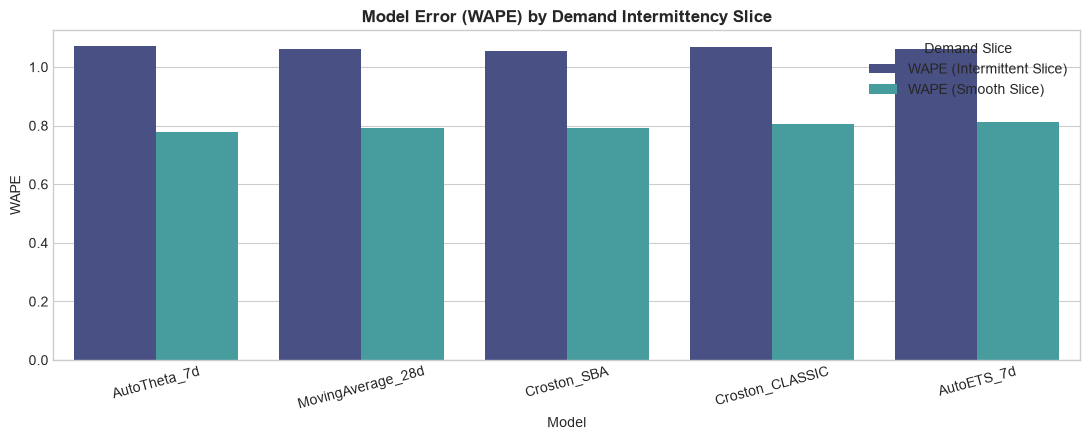

In [6]:
# Visual Slice Comparison
slice_melted = slice_df.melt(
    id_vars=["Model"],
    value_vars=["WAPE (Intermittent Slice)", "WAPE (Smooth Slice)"],
    var_name="Demand Slice",
    value_name="WAPE",
)

plt.figure(figsize=(11, 4.5))
sns.barplot(data=slice_melted, x="Model", y="WAPE", hue="Demand Slice", palette="mako")
plt.title("Model Error (WAPE) by Demand Intermittency Slice", fontweight="bold")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 5. Forecast Trajectory Overlay on Validation Horizon
We inspect actual vs predicted sales trajectories for an individual series across statistical models.

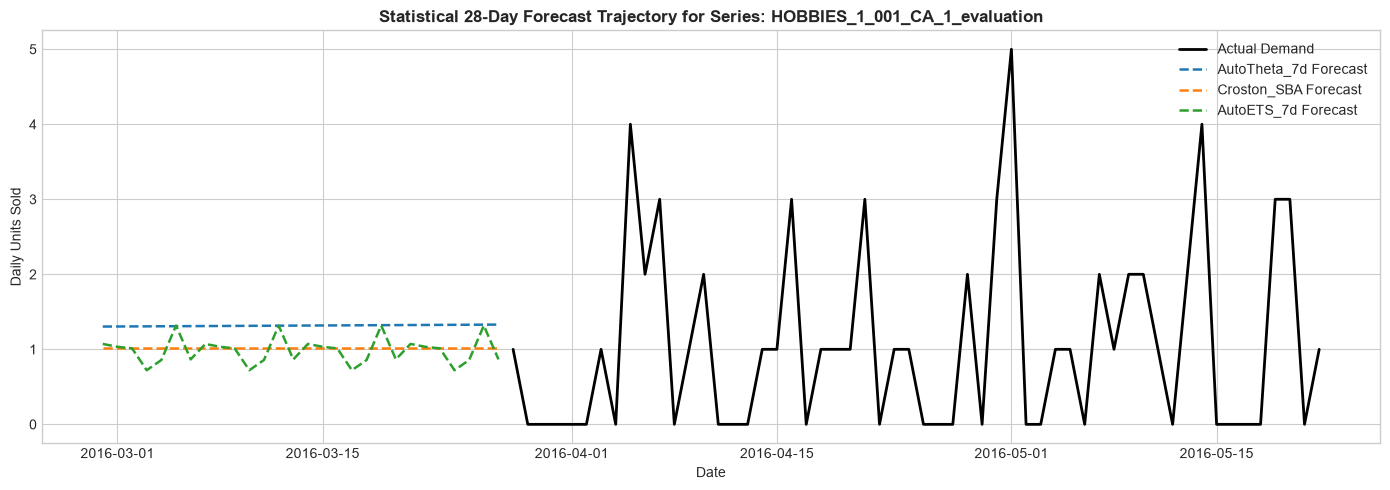

In [7]:
sample_sid = df["id"].iloc[0]
sample_fold_1_actual = df[df["id"] == sample_sid].sort_values("date").tail(56)

plt.figure(figsize=(14, 5))
plt.plot(
    sample_fold_1_actual["date"],
    sample_fold_1_actual["sales"],
    label="Actual Demand",
    color="black",
    lw=2,
)

for model_name in ["AutoTheta_7d", "Croston_SBA", "AutoETS_7d"]:
    if model_name in oof_predictions:
        m_oof = oof_predictions[model_name]
        m_sample = m_oof[(m_oof["id"] == sample_sid) & (m_oof["fold"] == 1)].sort_values("date")
        if not m_sample.empty:
            plt.plot(
                m_sample["date"],
                m_sample["y_pred"],
                label=f"{model_name} Forecast",
                lw=1.8,
                linestyle="--",
            )

plt.title(f"Statistical 28-Day Forecast Trajectory for Series: {sample_sid}", fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Daily Units Sold")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Summary & Machine Learning Handoff

### Key Takeaways:
1. **Statistical Strengths**: Fast inference and principled handling of pure temporal patterns (seasonality in AutoTheta, zero-intervals in Croston).
2. **The Exogenous Bottleneck**: Statistical models cannot natively exploit high-dimensional tabular features (SNAP flags per state, event calendars, price discounts, cross-item categories).
3. **Next Step (Phase 4)**: Build the leak-free tabular feature store (`src/features/`) and train **LightGBM / CatBoost** models with Tweedie loss to leverage all exogenous drivers.